Loading the Dataset using the format in the readMe file of https://github.com/zaidalyafeai/QuickDraw10/blob/master/README.md 

In [19]:
import numpy as np

train_data = np.load('dataset/train-ubyte.npz')
test_data  = np.load('dataset/test-ubyte.npz')

x_train, y_train = train_data['a'], train_data['b']
x_test,  y_test  = test_data['a'],  test_data['b']

Reshaping to perform PCA

In [20]:
x_train_new = x_train.reshape(len(x_train), -1)
x_test_new  = x_test.reshape(len(x_test), -1)

print(x_train_new.shape)
print(x_test_new.shape)

(80000, 784)
(20000, 784)


Performing PCA on the dataset to reduce its
dimensions. Then displaying the top 20 eigenvalues as well as
the representation of the samples projected onto
their first two and three principal components.

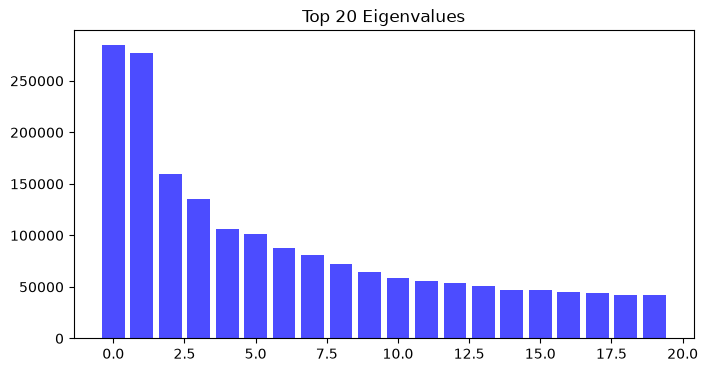

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(x_train_new)
egenvalues = pca.explained_variance_[:20]

plt.figure(figsize=(8, 4))
plt.bar(range(20), egenvalues, color='blue', alpha=0.7)
plt.title("Top 20 Eigenvalues")
plt.show()

samples projected onto
their first two and three principal components.

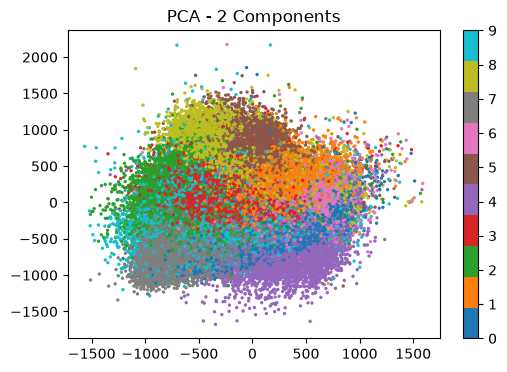

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='tab10', s=2)
plt.title("PCA - 2 Components")
plt.colorbar()
plt.show()

Now using LDA to project the samples onto their first
and second linear discriminants, and display the
results.

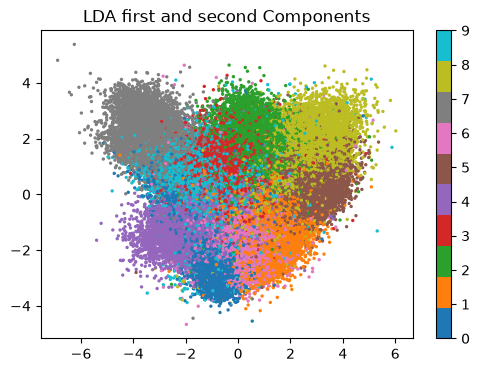

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(x_train_new, y_train)

plt.figure(figsize=(6, 4))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_train, cmap='tab10', s=2)
plt.title("LDA first and second Components")
plt.colorbar()
plt.show()

Performing K-Means on the data using their first two
principal components. Select random initial
centroids and set K = 3, 7, 10.

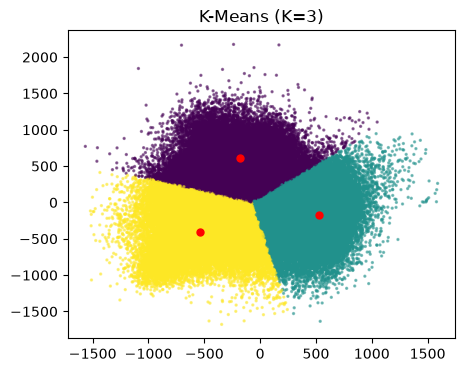

In [24]:
from sklearn.cluster import KMeans
X_pca2 = X_pca[:, :2]

kmeans3 = KMeans(
    n_clusters=3,
    init='random',
    n_init=10,
    random_state=42
)

clusters3 = kmeans3.fit_predict(X_pca2)

plt.figure(figsize=(5, 4))

plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=clusters3,
    cmap='viridis',
    s=2,
    alpha=0.5
)

plt.scatter(
    kmeans3.cluster_centers_[:, 0],
    kmeans3.cluster_centers_[:, 1],
    c='red',
    marker='.',
    s=100
)

plt.title("K-Means (K=3)")
plt.show()

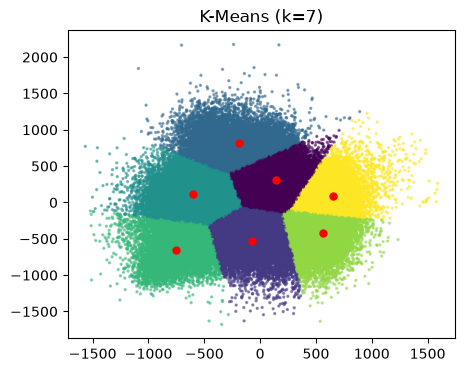

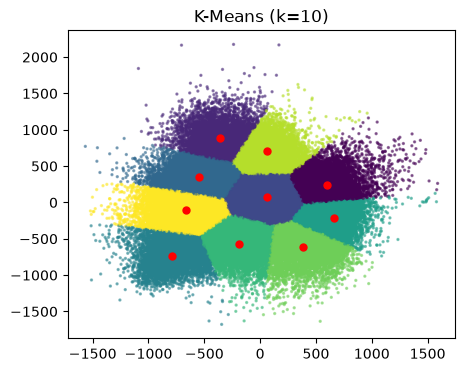

In [26]:
for k in [7, 10]:
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_pca2)
    
    plt.figure(figsize=(5, 4))
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=clusters, cmap='viridis', s=2, alpha=0.5)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='.', s=100)
    plt.title(f"K-Means (k={k})")
    plt.show()

Considering the initial centroids as
the mean of the samples such that for K = 3, initial
centroids are the mean of samples of classes
{1,3,5,7}, {2,4}, and {6,8,9,10}, for K = 7, initial
centroids are the mean of samples of classes {1,2,5},
used alternative for the MNIST
{3}, {4}, {6}, {7}, {9} and {8,10}, and for K = 10, initial centroids are the mean of sample of each of
dataset.
the 10 classes separately.

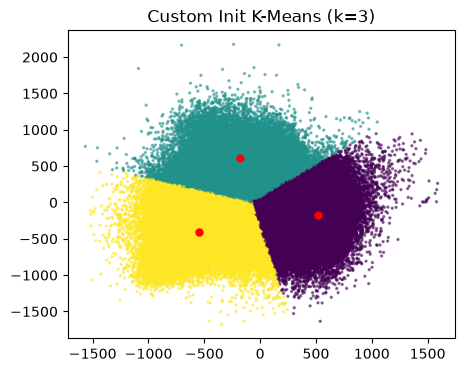

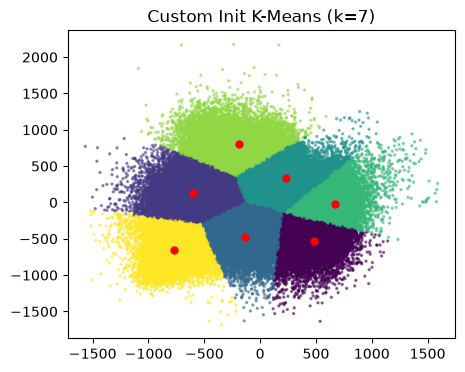

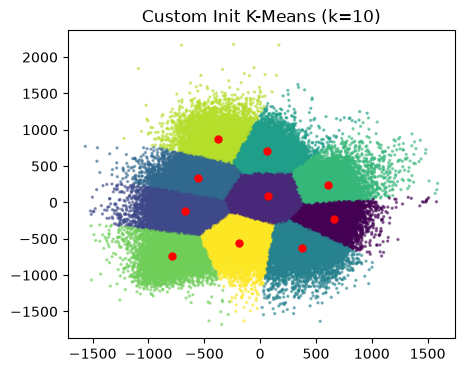

In [28]:
init_3 = []
for group in [[0, 2, 4, 6], [1, 3], [5, 7, 8, 9]]:
    group_data = X_pca2[np.isin(y_train, group)]
    init_3.append(np.mean(group_data, axis=0))
init_3 = np.array(init_3)

init_7 = []
for group in [[0, 1, 4], [2], [3], [5], [6], [8], [7, 9]]:
    group_data = X_pca2[np.isin(y_train, group)]
    init_7.append(np.mean(group_data, axis=0))
init_7 = np.array(init_7)

init_10 = []
for i in range(10):
    group_data = X_pca2[y_train == i]
    init_10.append(np.mean(group_data, axis=0))
init_10 = np.array(init_10)

inits = [init_3, init_7, init_10]
k_vals = [3, 7, 10]

for i in range(3):
    k = k_vals[i]
    kmeans = KMeans(n_clusters=k, init=inits[i]) 
    clusters = kmeans.fit_predict(X_pca2)
    
    plt.figure(figsize=(5, 4))
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=clusters, cmap='viridis', s=2, alpha=0.5)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='.', s=100)
    plt.title(f"Custom Init K-Means (k={k})")
    plt.show()

As can be seen, clustering the data using their first two principal components doesn’t produce
satisfactory results. We are going to increase the clustering accuracy by considering more
principal components. By trial and error find the number of principal components which is
enough to capture 0.95 of the data variance. We Reconstruct three arbitrary samples using these
principal components and compare the results with their corresponding original images.

Components for 0.95 of data variance: 271


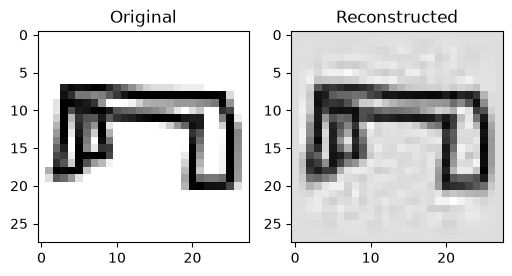

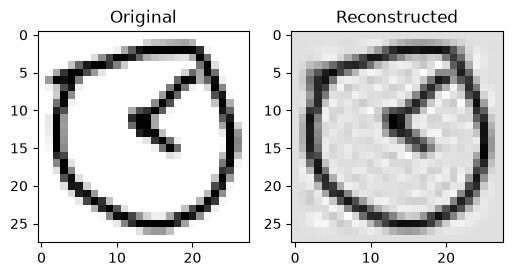

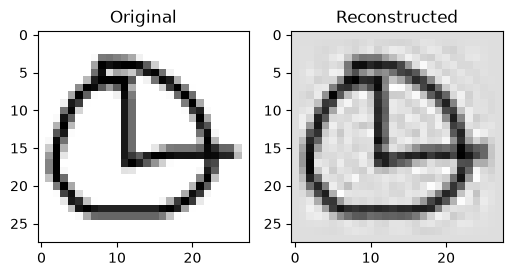

In [30]:
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(x_train_new)
print("Components for 0.95 of data variance:", pca_95.n_components_)

X_95 = pca_95.inverse_transform(X_pca_95)

samples = [0, 1, 2]
for idx in samples:
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title("Original")
    
    plt.subplot(1, 2, 2)
    plt.imshow(X_95[idx].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    
    plt.show()

Using K-Means to divide data into 10 clusters. Set the required parameters appropriately. Display
10 samples of each cluster randomly (100 in total).

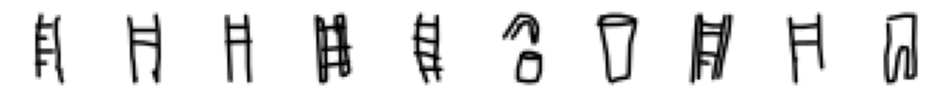

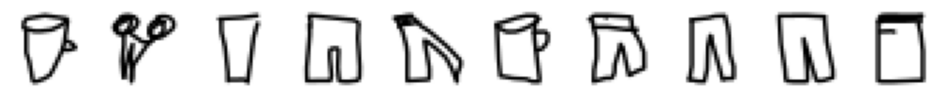

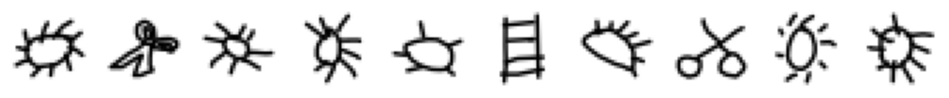

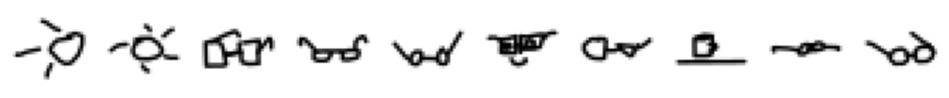

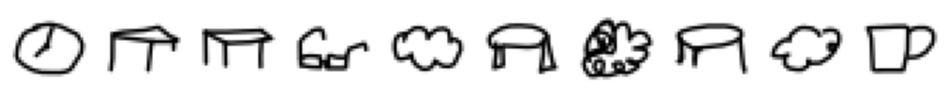

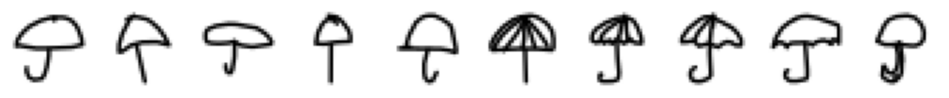

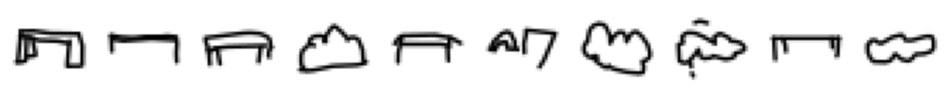

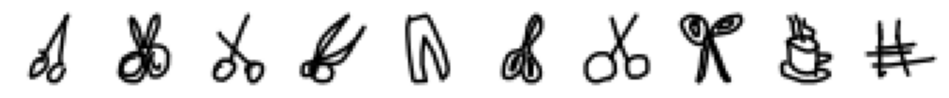

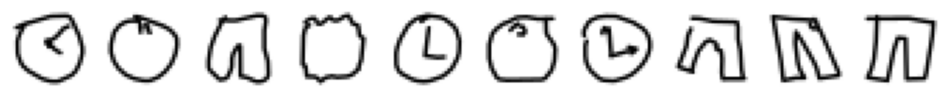

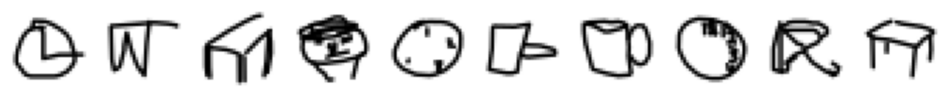

In [31]:
kmeans_final = KMeans(n_clusters=10, random_state=42)
final_clusters = kmeans_final.fit_predict(X_pca_95)

for c in range(10):

    samples = np.where(final_clusters == c)[0][:10]

    plt.figure(figsize=(12,2))

    for i, s in enumerate(samples):
        plt.subplot(1,10,i+1)
        plt.imshow(x_train[s], cmap='gray')
        plt.axis('off')

    plt.show()


Drawing 10 bar graphs for each cluster, each representing the distribution of the samples of
different classes (in percentage). Compare different clusters using these bar graphs.

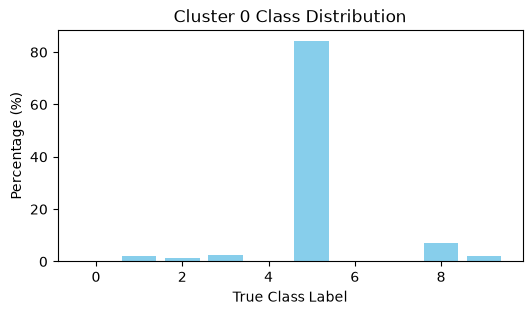

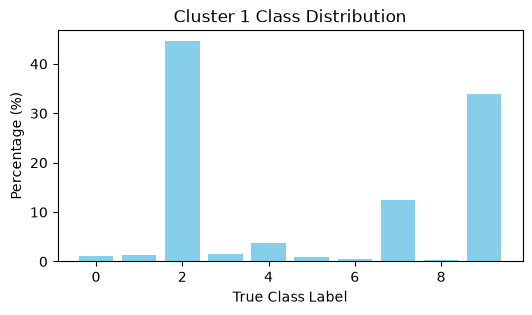

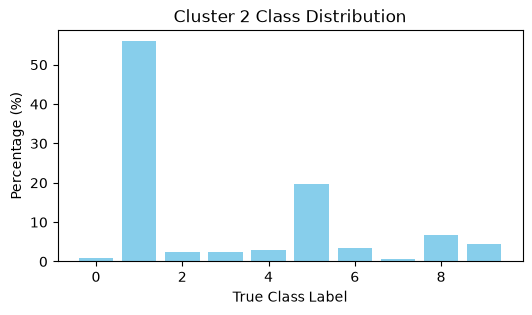

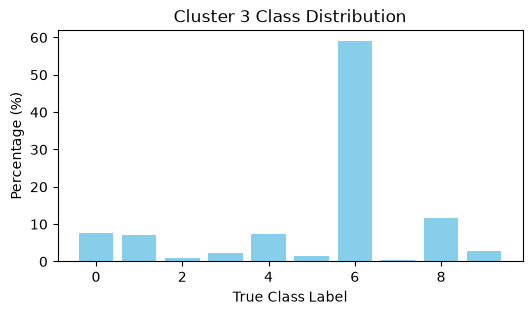

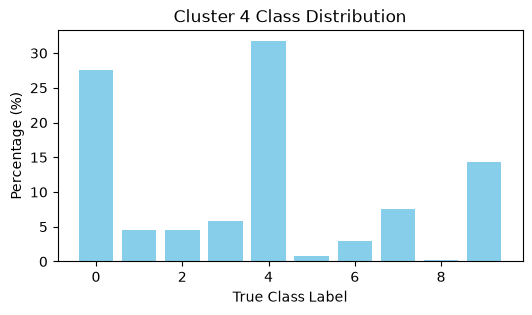

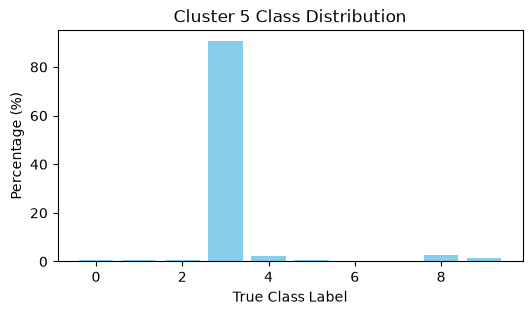

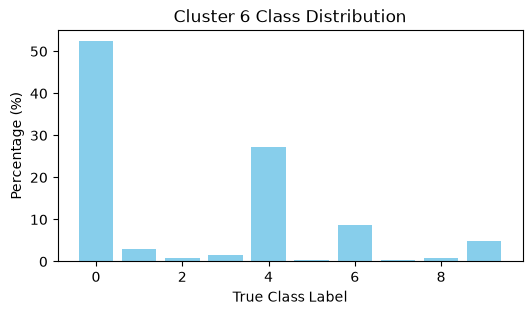

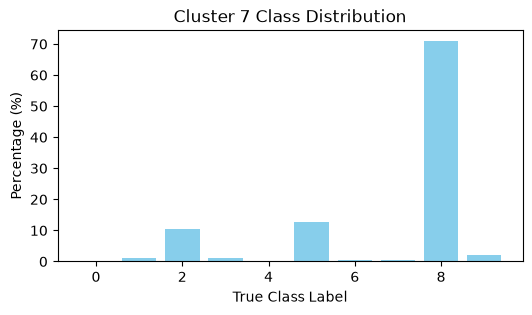

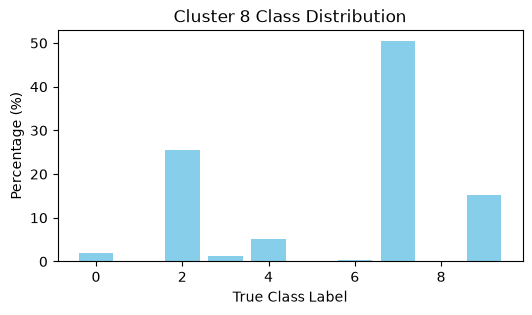

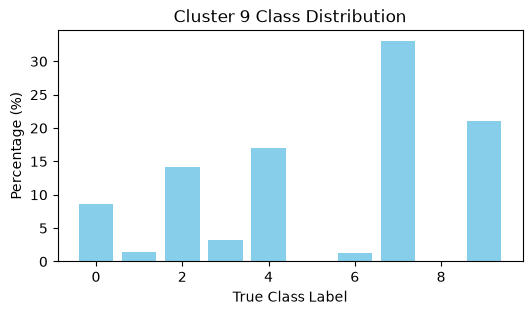

In [ ]:

for c in range(10):
    indices = np.where(final_clusters == c)[0]
    labels_in_cluster = y_train[indices]
    
    counts = []
    for class_label in range(10):
        # percentage
        percentage = np.sum(labels_in_cluster == class_label) / len(labels_in_cluster) * 100
        counts.append(percentage)
        
    plt.figure(figsize=(6, 3))
    plt.bar(range(10), counts, color='skyblue')
    plt.title(f"Cluster {c} Class Distribution")
    plt.xlabel("True Class Label")
    plt.ylabel("Percentage (%)")
    plt.show()

Finally, We visualize the clustering by keeping only 2 and 3 features and displaying the
corresponding scatter plots.

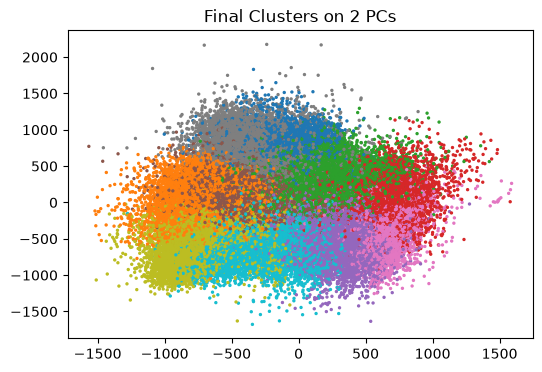

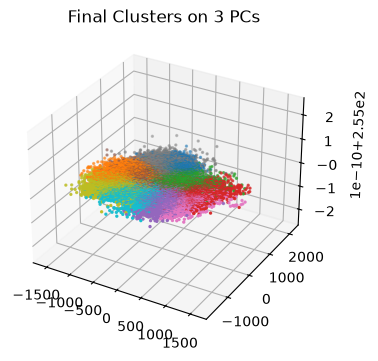

In [33]:

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_clusters, cmap='tab10', s=2)
plt.title("Final Clusters on 2 PCs")
plt.show()

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_95[:, 2], c=final_clusters, cmap='tab10', s=2)
ax.set_title("Final Clusters on 3 PCs")
plt.show()